## Step 1: Importing Necessary Libraries

This project will use Keras to train these models.

In [148]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
import numpy as np
import tensorflow as tf

In [ ]:
# The following code is from the download_data.py file in the kmnist GitHUb repository linked in the introduction of this project.
# The code prompts the user to select which version of the KMNIST dataset to download. In the case of this project,
# the Kuzujishi-49 dataset is used.

import requests

try:
    from tqdm import tqdm
except ImportError:
    tqdm = lambda x, total, unit: x  # If tqdm doesn't exist, replace it with a function that does nothing
    print('**** Could not import tqdm. Please install tqdm for download progressbars! (pip install tqdm) ****')

# Python2 compatibility
try:
    input = raw_input
except NameError:
    pass

download_dict = {
    '1) Kuzushiji-MNIST (10 classes, 28x28, 70k examples)': {
        '1) MNIST data format (ubyte.gz)':
            ['http://codh.rois.ac.jp/kmnist/dataset/kmnist/train-images-idx3-ubyte.gz',
            'http://codh.rois.ac.jp/kmnist/dataset/kmnist/train-labels-idx1-ubyte.gz',
            'http://codh.rois.ac.jp/kmnist/dataset/kmnist/t10k-images-idx3-ubyte.gz',
            'http://codh.rois.ac.jp/kmnist/dataset/kmnist/t10k-labels-idx1-ubyte.gz'],
        '2) NumPy data format (.npz)':
            ['http://codh.rois.ac.jp/kmnist/dataset/kmnist/kmnist-train-imgs.npz',
            'http://codh.rois.ac.jp/kmnist/dataset/kmnist/kmnist-train-labels.npz',
            'http://codh.rois.ac.jp/kmnist/dataset/kmnist/kmnist-test-imgs.npz',
            'http://codh.rois.ac.jp/kmnist/dataset/kmnist/kmnist-test-labels.npz'],
    },
    '2) Kuzushiji-49 (49 classes, 28x28, 270k examples)': {
        '1) NumPy data format (.npz)':
            ['http://codh.rois.ac.jp/kmnist/dataset/k49/k49-train-imgs.npz',
            'http://codh.rois.ac.jp/kmnist/dataset/k49/k49-train-labels.npz',
            'http://codh.rois.ac.jp/kmnist/dataset/k49/k49-test-imgs.npz',
            'http://codh.rois.ac.jp/kmnist/dataset/k49/k49-test-labels.npz'],
    },
    '3) Kuzushiji-Kanji (3832 classes, 64x64, 140k examples)': {
        '1) Folders of images (.tar)':
            ['http://codh.rois.ac.jp/kmnist/dataset/kkanji/kkanji.tar'],
    }

}

# Download a list of files
def download_list(url_list):
    for url in url_list:
        path = url.split('/')[-1]
        r = requests.get(url, stream=True)
        with open(path, 'wb') as f:
            total_length = int(r.headers.get('content-length'))
            print('Downloading {} - {:.1f} MB'.format(path, (total_length / 1024000)))

            for chunk in tqdm(r.iter_content(chunk_size=1024), total=int(total_length / 1024) + 1, unit="KB"):
                if chunk:
                    f.write(chunk)
    print('All dataset files downloaded!')

# Ask the user about which path to take down the dict
def traverse_dict(d):
    print('Please select a download option:')
    keys = sorted(d.keys())  # Print download options
    for key in keys:
        print(key)

    userinput = input('> ').strip()

    try:
        selection = int(userinput) - 1
    except ValueError:
        print('Your selection was not valid')
        traverse_dict(d)  # Try again if input was not valid
        return

    selected = keys[selection]

    next_level = d[selected]
    if isinstance(next_level, list):  # If we've hit a list of downloads, download that list
        download_list(next_level)
    else:
        traverse_dict(next_level)     # Otherwise, repeat with the next level

traverse_dict(download_dict)

Please select a download option:
1) Kuzushiji-MNIST (10 classes, 28x28, 70k examples)
2) Kuzushiji-49 (49 classes, 28x28, 270k examples)
3) Kuzushiji-Kanji (3832 classes, 64x64, 140k examples)


## Step 2: Loading and Pre-Processing Data
---
To use the data downloaded in step one, it must be converted from a NumPy array into a Tensor that can be used with PyTorch.
Additionally, the pixel values must be normalized - as the KMNIST dataset was initially designed to be a drop-in replacement for the MINIST datset (with 28x28 pixel size and pixel values in the range [0,255]), using data-preprocessing for MNIST will yield the desired normalization.


In [4]:
# Load the data and convert them from NumPy arrays to Tensors
# Information on how to do this from:
# https://www.w3resource.com/python-exercises/numpy/save-and-load-a-large-numpy-array-to-and-from-a-compressed-dot-npz-file.php

# First, the data is loaded from compressed .npz files from download in Step 1
train_data_loader = np.load ("./data/k49-train-imgs.npz")
test_data_loader = np.load ("./data/k49-test-imgs.npz")

train_labels_loader = np.load ("./data/k49-train-labels.npz")
test_labels_loader = np.load ("./data/k49-test-labels.npz")

# Second, the data is then read into a NumPy ndarray
train_labels_arr = train_labels_loader['arr_0.npy']
train_data_arr = train_data_loader['arr_0.npy']

test_labels_arr = test_labels_loader['arr_0.npy']
test_data_arr = test_data_loader['arr_0.npy']

# Show some of the test_label values
print(train_data_arr.shape)
print(train_labels_arr.shape)

(232365, 28, 28)
(232365,)


In [ ]:
# Convert all data into arrays with dtype = float

train_data = train_data_arr.astype(float)
train_labels = train_labels_arr.astype(float)
test_data = test_data_arr.astype(float)
test_labels = test_labels_arr.astype(float)

# Show labels again to compare and verify data imported correctly
train_data.dtype


dtype('float64')

In [6]:
# Normalize the data pixel values from [0,255] to [0,1]
# Code sourced from Image Classification example on D2L

train_data = train_data / 255.0

test_data = test_data / 255.0

## Step 3: Defining parameters of CNN and MLP Model
---


In [ ]:
# Code Sourced from Image Classification Example
# Additional ReLU layer and linear layer added for multiple layer perceptron
MLP_model = tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape=(28, 28)),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(128, activation='linear'),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(49)
])

C:\Users\Amai\AppData\Roaming\Python\Python312\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
# Code Sourced from Image Classification Example 
# Additional convolutional layers added to create CNN, param adapted A3 solution
# Order of layers from: https://github.com/rois-codh/kmnist/blob/master/benchmarks/kuzushiji_mnist_cnn.py

CNN_model = tf.keras.Sequential([
    tf.keras.layers.Conv2D(32, kernel_size=3, activation="relu"),
    tf.keras.layers.Conv2D(64, kernel_size=3, activation="relu"),
    tf.keras.layers.MaxPool2D((2,2)),
    tf.keras.layers.Conv2D(128, kernel_size=3, activation="relu"),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation="linear"),
    tf.keras.layers.Dropout(0.25),
    tf.keras.layers.Dense(49, activation="softmax")
])


## Step 4: Provide definition for Loss Function and Optimizer


In [ ]:
# Code Sourced from Image Classification Example 

MLP_model.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])

CNN_model.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])


## Step 5: Training and Testing Loops


In [ ]:
# Code Sourced from Image Classification Example

MLP_model.fit(train_data, train_labels, epochs=10)

Epoch 1/10
7262/7262 ━━━━━━━━━━━━━━━━━━━━ 21s 3ms/step - accuracy: 0.7831 - loss: 0.8043
Epoch 2/10
7262/7262 ━━━━━━━━━━━━━━━━━━━━ 19s 3ms/step - accuracy: 0.8579 - loss: 0.5081
Epoch 3/10
7262/7262 ━━━━━━━━━━━━━━━━━━━━ 19s 3ms/step - accuracy: 0.8758 - loss: 0.4422
Epoch 4/10
7262/7262 ━━━━━━━━━━━━━━━━━━━━ 19s 3ms/step - accuracy: 0.8866 - loss: 0.4028
Epoch 5/10
7262/7262 ━━━━━━━━━━━━━━━━━━━━ 19s 3ms/step - accuracy: 0.8924 - loss: 0.3803
Epoch 6/10
7262/7262 ━━━━━━━━━━━━━━━━━━━━ 19s 3ms/step - accuracy: 0.8972 - loss: 0.3625
Epoch 7/10
7262/7262 ━━━━━━━━━━━━━━━━━━━━ 19s 3ms/step - accuracy: 0.9006 - loss: 0.3462
Epoch 8/10
7262/7262 ━━━━━━━━━━━━━━━━━━━━ 19s 3ms/step - accuracy: 0.9044 - loss: 0.3350
Epoch 9/10
7262/7262 ━━━━━━━━━━━━━━━━━━━━ 19s 3ms/step - accuracy: 0.9068 - loss: 0.3244
Epoch 10/10
7262/7262 ━━━━━━━━━━━━━━━━━━━━ 20s 3ms/step - accuracy: 0.9092 - loss: 0.3167


In [137]:
# Code Sourced from Image Classification Example on D2L

cnn_train_data = train_data.reshape(train_data.shape[0], 28, 28, 1)
CNN_model.fit(cnn_train_data, train_labels, epochs=5)

Epoch 1/5
7262/7262 ━━━━━━━━━━━━━━━━━━━━ 277s 38ms/step - accuracy: 0.8971 - loss: 0.3835
Epoch 2/5
7262/7262 ━━━━━━━━━━━━━━━━━━━━ 278s 38ms/step - accuracy: 0.9514 - loss: 0.1737
Epoch 3/5
7262/7262 ━━━━━━━━━━━━━━━━━━━━ 284s 39ms/step - accuracy: 0.9642 - loss: 0.1224
Epoch 4/5
7262/7262 ━━━━━━━━━━━━━━━━━━━━ 352s 49ms/step - accuracy: 0.9708 - loss: 0.0960
Epoch 5/5
7262/7262 ━━━━━━━━━━━━━━━━━━━━ 281s 39ms/step - accuracy: 0.9757 - loss: 0.0783


## Step 6: Run the Training Loop and Evaluate Performance


In [ ]:
# Code Sourced from Image Classification Example 
# Test MLP Model performance

test_loss, test_acc = MLP_model.evaluate(test_data,  test_labels, verbose=2)

print('\nTest accuracy:', test_acc)

1205/1205 - 2s - 2ms/step - accuracy: 0.8070 - loss: 0.8497

Test accuracy: 0.8069629073143005


In [ ]:
# Code Sourced from Image Classification Example 
# Test CNN Model

test_loss, test_acc = CNN_model.evaluate(test_data,  test_labels, verbose=2)
print('\nTest accuracy:', test_acc)

C:\Users\Amai\AppData\Roaming\Python\Python312\site-packages\keras\src\backend\tensorflow\nn.py:717: UserWarning: "`sparse_categorical_crossentropy` received `from_logits=True`, but the `output` argument was produced by a Softmax activation and thus does not represent logits. Was this intended?
  output, from_logits = _get_logits(


1205/1205 - 10s - 8ms/step - accuracy: 0.9227 - loss: 0.4012

Test accuracy: 0.9226658344268799


## Step 7: Visualize Results - Confusion Matrix, Plotting Loss for Each Model

In [ ]:
# Code Sourced from Image Classification Example 

probability_model = tf.keras.Sequential([MLP_model, 
                                         tf.keras.layers.Softmax()])

predictions = probability_model.predict(test_data)
predictions[0]
predictions.shape

1205/1205 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step


(38547, 49)

In [ ]:
# Code Sourced from Image Classification Example
#  CNN Predictions

cnn_predictions = CNN_model.predict(test_data)
cnn_predictions.shape

1205/1205 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step


(38547, 49)

In [ ]:
# Code Sourced from Image CLassification Example

def plot_image(i, predictions_array, true_label, img):
  true_label, img = true_label[i], img[i]
  plt.grid(False)
  plt.xticks([])
  plt.yticks([])

  plt.imshow(img, cmap=plt.cm.binary)

  predicted_label = np.argmax(predictions_array)
  if predicted_label == true_label:
    color = 'blue'
  else:
    color = 'red'

  plt.xlabel("{} {:2.0f}% ({})".format(predicted_label,
                                100*np.max(predictions_array),
                                true_label),
                                color=color)

def plot_value_array(i, predictions_array, true_label):
  true_label = true_label[i]
  plt.grid(False)
  plt.xticks(range(49))
  plt.yticks([])
  thisplot = plt.bar(range(49), predictions_array, color="#777777")
  plt.ylim([0, 1])
  predicted_label = np.argmax(predictions_array)

  thisplot[predicted_label].set_color('red')
  thisplot[true_label].set_color('blue')

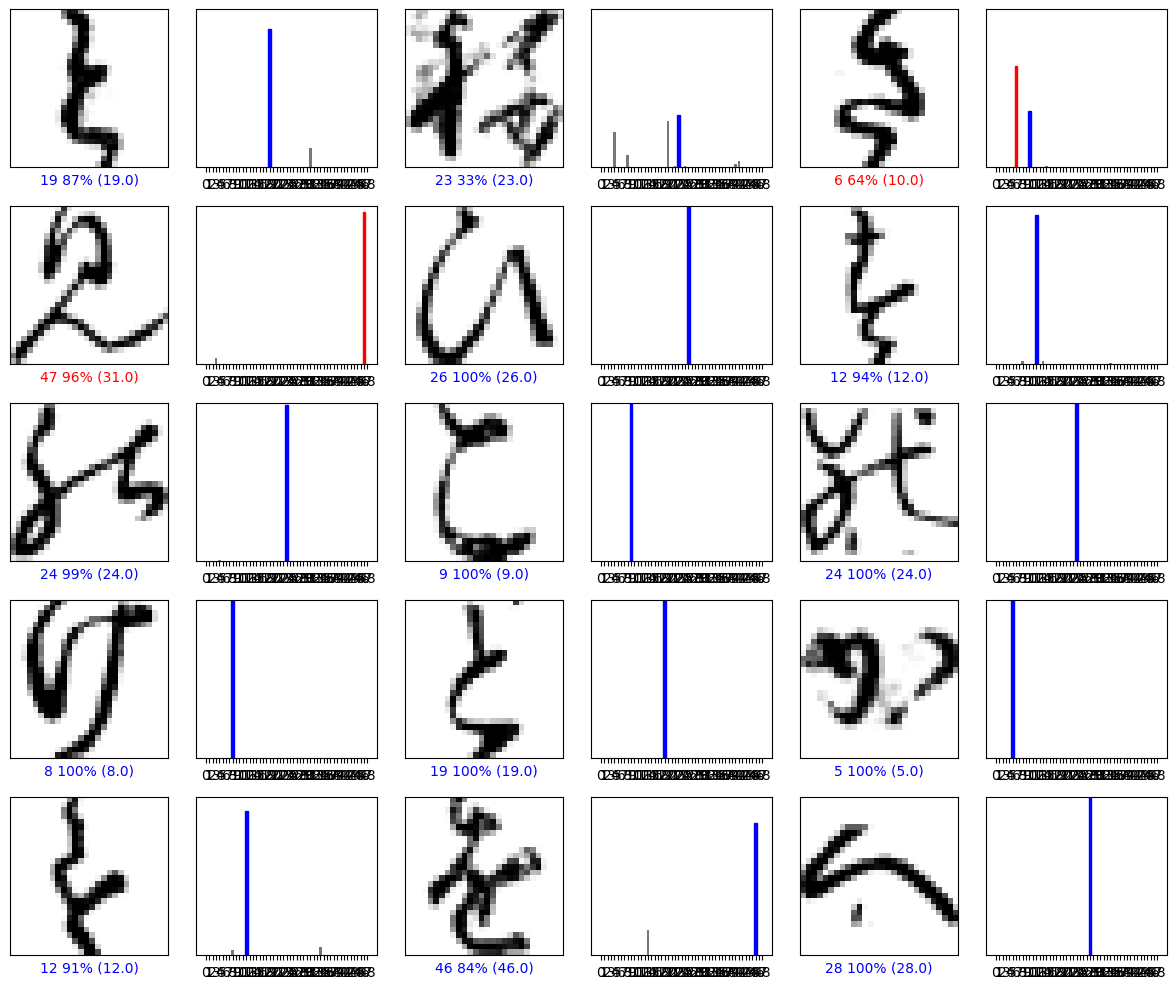

In [ ]:
# Plot the first X test images, their predicted labels, and the true labels.
# Color correct predictions in blue and incorrect predictions in red.
# Graphs of first 15 MLP model predictions

# Code sourced from Image Classification Example
num_rows = 5
num_cols = 3
num_images = num_rows*num_cols
plt.figure(figsize=(2*2*num_cols, 2*num_rows))
for i in range(num_images):
  plt.subplot(num_rows, 2*num_cols, 2*i+1)
  plot_image(i, predictions[i], test_labels, test_data)
  plt.subplot(num_rows, 2*num_cols, 2*i+2)
  plot_value_array(i, predictions[i], test_labels.astype(int))
plt.tight_layout()
plt.show()

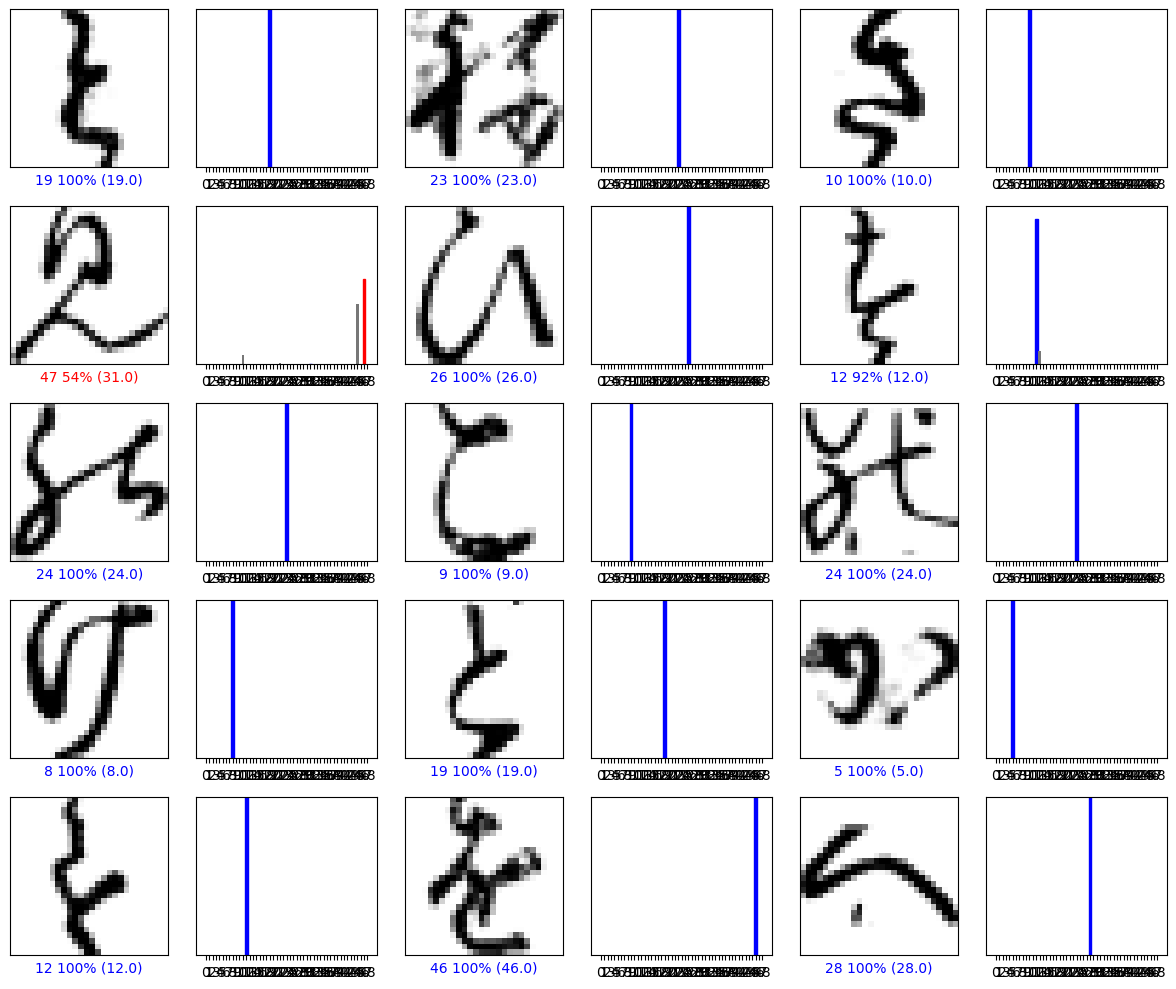

In [ ]:
# Plot the first X test images, their predicted labels, and the true labels.
# Color correct predictions in blue and incorrect predictions in red.
# Graphs of first 15 CNN model predictions

# Code sourced from Image Classification Example
num_rows = 5
num_cols = 3
num_images = num_rows*num_cols
plt.figure(figsize=(2*2*num_cols, 2*num_rows))
for i in range(num_images):
  plt.subplot(num_rows, 2*num_cols, 2*i+1)
  plot_image(i, cnn_predictions[i], test_labels, test_data)
  plt.subplot(num_rows, 2*num_cols, 2*i+2)
  plot_value_array(i, cnn_predictions[i], test_labels.astype(int))
plt.tight_layout()
plt.show()

In [ ]:
# Code to pull predicted class from MLP model probability predictions

max_pred = []


for i in range(len(predictions)):
    max_pred.append(np.argmax(predictions[i]))

print(max_pred[0])
len(max_pred)

19


49

In [ ]:
# Code to pull predicted class from CNN model probability predictions
cnn_max_pred = []
for i in range(len(cnn_predictions)):
    cnn_max_pred.append(np.argmax(cnn_predictions[i]))

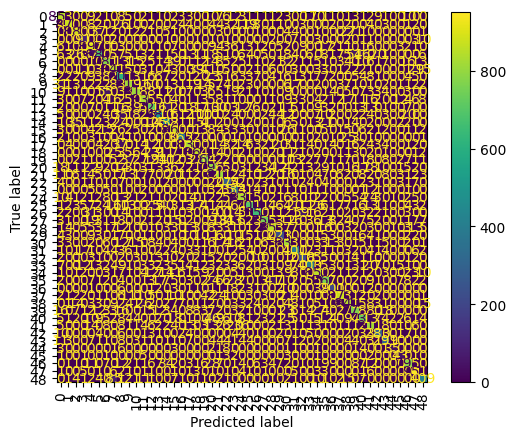

              precision    recall  f1-score   support

         0.0       0.81      0.86      0.83      1000
         1.0       0.95      0.88      0.91      1000
         2.0       0.89      0.89      0.89      1000
         3.0       0.54      0.72      0.62       126
         4.0       0.78      0.90      0.83      1000
         5.0       0.83      0.68      0.75      1000
         6.0       0.83      0.78      0.80      1000
         7.0       0.80      0.85      0.82      1000
         8.0       0.60      0.79      0.68       767
         9.0       0.85      0.82      0.83      1000
        10.0       0.90      0.81      0.85      1000
        11.0       0.85      0.83      0.84      1000
        12.0       0.78      0.73      0.75      1000
        13.0       0.75      0.72      0.74       678
        14.0       0.64      0.69      0.66       629
        15.0       0.77      0.87      0.81      1000
        16.0       0.91      0.87      0.89       418
        17.0       0.84    

In [ ]:
# Confusion Matrix for MLP Model

cm = confusion_matrix(test_labels, max_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(xticks_rotation='vertical')
plt.show()

report = classification_report(test_labels, max_pred)
print(report)

print(cm)

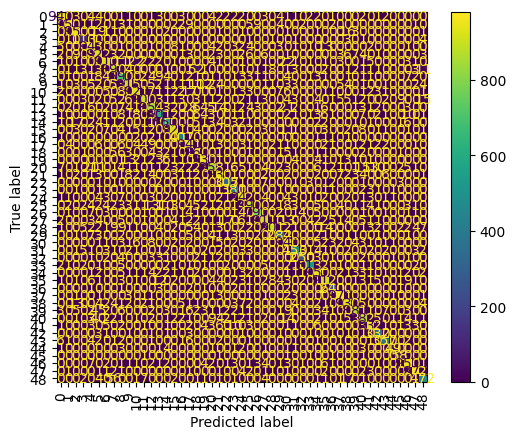

              precision    recall  f1-score   support

         0.0       0.96      0.95      0.95      1000
         1.0       0.98      0.95      0.97      1000
         2.0       0.94      0.95      0.94      1000
         3.0       0.82      0.90      0.86       126
         4.0       0.90      0.94      0.92      1000
         5.0       0.83      0.93      0.88      1000
         6.0       0.94      0.91      0.93      1000
         7.0       0.90      0.90      0.90      1000
         8.0       0.84      0.91      0.87       767
         9.0       0.94      0.91      0.93      1000
        10.0       0.93      0.92      0.93      1000
        11.0       0.97      0.91      0.94      1000
        12.0       0.90      0.86      0.88      1000
        13.0       0.89      0.89      0.89       678
        14.0       0.90      0.89      0.89       629
        15.0       0.95      0.93      0.94      1000
        16.0       0.93      0.97      0.95       418
        17.0       0.89    

In [ ]:
# Confusion Matrix for CNN Model
# Code sourced from Image Classification Example 

cnn_cm = confusion_matrix(test_labels, cnn_max_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cnn_cm)
disp.plot(xticks_rotation='vertical')
plt.show()

report = classification_report(test_labels, cnn_max_pred)
print(report)

print(cnn_cm)